In [1]:
# Standard imports
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Project modules
from src.data.preprocess import load_and_clean_data
from src.features.build_features import engineer_features, create_full_pipeline
from src.models.cluster import (
    find_optimal_k, 
    kmeans_clustering, 
    dbscan_clustering, 
    hierarchical_clustering,
    plot_dendrogram
)

plt.style.use('seaborn-v0_8')
np.random.seed(42)
print("Setup complete.")

Setup complete.


In [2]:
# Load raw data and separate labels
data, labels = load_and_clean_data("data/raw/ai4i2020.csv")
print(f"Original features shape: {data.shape}")

# Feature engineering
data_eng = engineer_features(data)
print("Engineered features:", data_eng.columns.tolist())

# Full preprocessing + PCA pipeline
# Determine n_components after preprocessing
from src.data.preprocess import build_preprocessing_pipeline
pre = build_preprocessing_pipeline()
X_pre = pre.fit_transform(data_eng)
n_components = 0.81 #min(8, X_pre.shape[1], X_pre.shape[0])
print(f"Using PCA n_components={n_components}")
pipeline = create_full_pipeline(n_components=n_components)
X_scaled = pipeline.fit_transform(data_eng)

print(f"Final feature matrix shape: {X_scaled.shape}")
print("Cumulative explained variance:", 
      np.cumsum(pipeline.named_steps['pca'].explained_variance_ratio_))

INFO:root:Resolved full path: C:\ws-python\predictive-maintenance-clustering\data\raw\ai4i2020.csv
INFO:root:Loaded dataset with shape: (10000, 14)
INFO:root:Features shape: (10000, 6) | Labels shape: (10000, 6)


Original features shape: (10000, 6)
Engineered features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'power_proxy', 'wear_rate_proxy']
Using PCA n_components=0.81
Final feature matrix shape: (10000, 3)
Cumulative explained variance: [0.35060422 0.68838537 0.87180601]


=== K-Means: Finding Optimal k ===


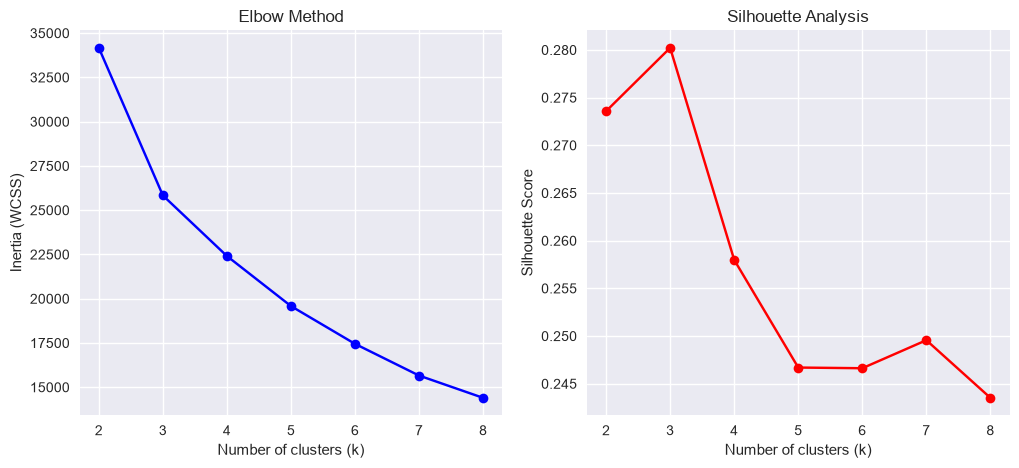

In [3]:
print("=== K-Means: Finding Optimal k ===")
inertias, sil_scores = find_optimal_k(X_scaled, max_k=8)

# Choose best k based on plots (usually 3-5 for this dataset)
best_k = 4  # ← Adjust after viewing plots

=== Training K-Means ===


INFO:root:K-Means (k=4) - Silhouette: 0.2580, DB: 1.2039



=== Training DBSCAN ===


INFO:root:DBSCAN (eps=0.55, min_samples=8) - Clusters: 2, Silhouette: 0.2814



=== Training Hierarchical Clustering ===


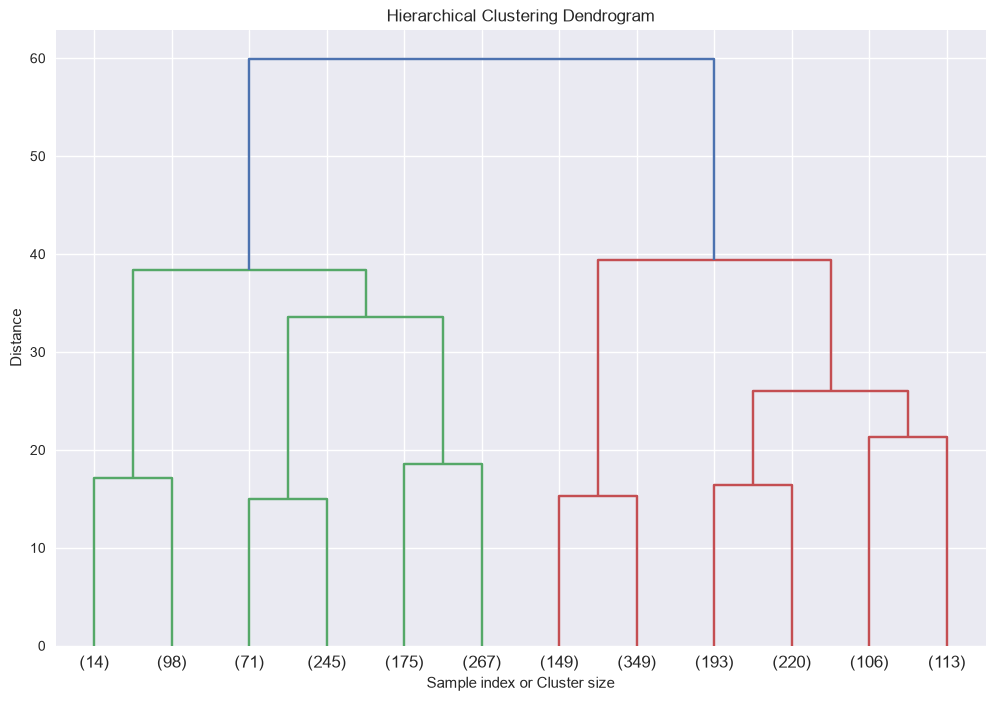

INFO:root:Hierarchical (n=4) - Silhouette: 0.2054, DB: 1.4320


In [ ]:
print("=== Training K-Means ===")
kmeans_model, kmeans_labels, k_sil, k_db = kmeans_clustering(X_scaled, n_clusters=best_k)

print("\n=== Training DBSCAN ===")
# Tip: First run k-distance plot to find good eps
# from sklearn.neighbors import NearestNeighbors
# nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
# distances, _ = nbrs.kneighbors(X_scaled)
# distances = np.sort(distances[:,4])
# plt.plot(distances); plt.title("k-distance plot"); plt.show()

db_model, db_labels, db_sil, db_db = dbscan_clustering(X_scaled, eps=0.55, min_samples=8)
#eps = 0.55 by far gives the highest silhouette score giving out 2 clusters
print("\n=== Training Hierarchical Clustering ===")
plot_dendrogram(X_scaled[:2000], method='ward')   # subsample for speed
hier_model, hier_labels, h_sil, h_db = hierarchical_clustering(X_scaled, n_clusters=best_k)

In [14]:
comparison = pd.DataFrame({
    'Model': ['K-Means (k=4)', 'DBSCAN', 'Hierarchical (k=4)'],
    'Silhouette Score': [k_sil, db_sil, h_sil],
    'Davies-Bouldin Index': [k_db, db_db, h_db],
    'Notes': [
        'Interpretable centroids',
        'Good for anomaly detection (noise points)',
        'Visual hierarchy'
    ]
})

comparison_rounded = comparison.round(4)
display(comparison_rounded)

#print(comparison_rounded.to_string(index=False))

,Model,Silhouette Score,Davies-Bouldin Index,Notes
0,K-Means (k=4),0.2580,1.2039,Interpretable centroids
1,DBSCAN,0.2814,0.6144,Good for anomaly detection (noise points)
2,Hierarchical (k=4),0.2054,1.4320,Visual hierarchy


In [15]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

import joblib
import os

os.makedirs("models", exist_ok=True)

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Save champion (DBSCAN recommended)
joblib.dump(db_model, models_dir / "champion_dbscan.pkl")
joblib.dump(pipeline, models_dir /"preprocessing_pipeline.pkl")

# Optional: Save labels for analysis in next step
pd.DataFrame({
    'kmeans_cluster': kmeans_labels,
    'dbscan_cluster': db_labels,
    'hier_cluster': hier_labels
}).to_csv("../data/processed/cluster_assignments.csv", index=False)

print("✅ Champion model and pipeline saved to models/")
print("Cluster assignments saved to data/processed/")

✅ Champion model and pipeline saved to models/
Cluster assignments saved to data/processed/


In [16]:
# Add clusters back to original data for inspection
data_with_clusters = data_eng.copy()
data_with_clusters['cluster'] = kmeans_labels

# Cluster centroids (on scaled data)
pca_centroids = pipeline.named_steps['pca'].inverse_transform(kmeans_model.cluster_centers_)
centroid_columns = pipeline.named_steps['preprocessor'].get_feature_names_out()
centroids = pd.DataFrame(
    pca_centroids,
    columns=centroid_columns
)
print("Cluster Centroids (preprocessed feature space):")
display(centroids.round(3))

# Size of each cluster
print("\nCluster Sizes:")
print(data_with_clusters['cluster'].value_counts().sort_index())

Cluster Centroids (preprocessed feature space):


,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],cat__Type_L,cat__Type_M
0,-0.960,-0.959,-0.343,0.335,-0.057,0.596,0.297
1,0.690,0.690,-0.263,0.266,0.965,0.608,0.297
2,0.750,0.751,-0.350,0.359,-0.868,0.596,0.308
3,-0.023,-0.026,1.507,-1.507,-0.033,0.602,0.297



Cluster Sizes:
cluster
0    3507
1    2383
2    2349
3    1761
Name: count, dtype: int64
